# 00 - Setup & device check

Run this once. It answers one question: **does this machine actually do computer vision?**

If every cell below runs green, you never have to think about installation again for
assignments 01-04, and you can go straight to writing code.

**Interpreter this lab expects:** `/Library/Frameworks/Python.framework/Versions/3.12/bin/python3`
(Python 3.12.5 - it already has opencv, torch, numpy, matplotlib).
Pick that one as the notebook kernel. Do **not** use Python 3.14 from Homebrew: most
CV wheels do not exist for 3.14 yet.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import sys, platform, cv2, numpy as np, matplotlib
print("python     ", sys.version.split()[0], "at", sys.executable)
print("macOS      ", platform.mac_ver()[0], platform.machine())
print("opencv     ", cv2.__version__)
print("numpy      ", np.__version__)
print("matplotlib ", matplotlib.__version__)
print("cv2 threads", cv2.getNumThreads())

python      3.12.5 at /Users/manankapoor/cv/bin/python
macOS       26.5.1 arm64
opencv      4.11.0
numpy       2.5.2
matplotlib  3.11.1
cv2 threads 8


## Is the GPU usable?

Apple Silicon has no CUDA. PyTorch talks to the 8-core M2 GPU through **MPS**
(Metal Performance Shaders). `mps` is your `cuda`. Everywhere a tutorial says
`.to("cuda")`, you write `.to("mps")`.

In [2]:
import torch
print("torch      ", torch.__version__)
print("mps built  ", torch.backends.mps.is_built())
print("mps ready  ", torch.backends.mps.is_available())
DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
print("device ->  ", DEVICE)

torch       2.13.0
mps built   True
mps ready   True
device ->   mps


In [3]:
# A ~11 GFLOP forward pass at 640x640 -- roughly one YOLOv8n frame's worth of work.
import time
from torchvision.models import resnet18

def bench(fn, n=10, warm=3):
    for _ in range(warm): fn()
    if DEVICE == "mps": torch.mps.synchronize()
    t0 = time.perf_counter()
    for _ in range(n): fn()
    if DEVICE == "mps": torch.mps.synchronize()
    return (time.perf_counter() - t0) / n * 1000

m = resnet18().eval()
x = torch.randn(1, 3, 640, 640)
with torch.no_grad():
    cpu_ms = bench(lambda: m(x), 3)
    mg, xg = m.to(DEVICE), x.to(DEVICE)
    gpu_ms = bench(lambda: mg(xg), 10)
print(f"CPU  {cpu_ms:6.1f} ms/frame  ({1000/cpu_ms:5.1f} fps)")
print(f"{DEVICE.upper():4} {gpu_ms:6.1f} ms/frame  ({1000/gpu_ms:5.1f} fps)   speedup x{cpu_ms/gpu_ms:.1f}")

CPU   102.7 ms/frame  (  9.7 fps)
MPS    19.9 ms/frame  ( 50.2 fps)   speedup x5.2


## Classic OpenCV throughput

These run on the CPU (OpenCV does not use the Apple GPU). They are the operations
you will spend assignments 01-04 on, so it is worth knowing they are effectively free.

In [4]:
img = cv2.imread("images/lena.jpg")
big = cv2.resize(img, (1920, 1080))
g   = cv2.cvtColor(big, cv2.COLOR_BGR2GRAY)

def t(fn, n=30):
    for _ in range(3): fn()
    t0 = time.perf_counter()
    for _ in range(n): fn()
    return (time.perf_counter() - t0) / n * 1000

print(f"1080p grayscale convert : {t(lambda: cv2.cvtColor(big, cv2.COLOR_BGR2GRAY)):6.2f} ms")
print(f"1080p 15x15 Gaussian    : {t(lambda: cv2.GaussianBlur(big, (15,15), 0)):6.2f} ms")
print(f"1080p Canny edges       : {t(lambda: cv2.Canny(g, 100, 200)):6.2f} ms")
print(f"1080p SIFT keypoints    : {t(lambda: cv2.SIFT_create().detectAndCompute(g, None), 3):6.1f} ms")

1080p grayscale convert :   0.15 ms
1080p 15x15 Gaussian    :   3.44 ms
1080p Canny edges       :   1.07 ms
1080p SIFT keypoints    :  203.1 ms


## No helper module

There is no `cvlab.py` and there are no helper functions. Every cell writes out the real calls:
`cv2.imread`, `cv2.cvtColor`, `plt.imshow`, `plt.hist`. The repetition is deliberate. After typing
them fifty times you will never need to look them up.

Testing works the same way. After each task there is a list of properties your function must
satisfy, and **you** write the `assert`s that check them.

rgb : shape=(512, 512, 3)  dtype=uint8  min=0  max=255


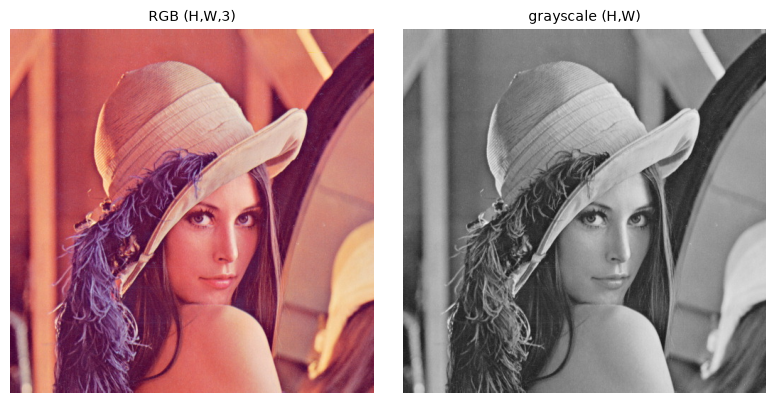

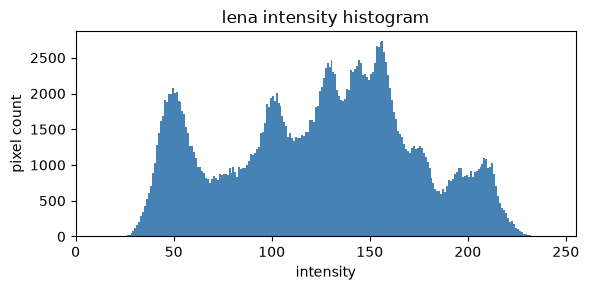

In [5]:
import cv2
import matplotlib.pyplot as plt

rgb  = cv2.cvtColor(cv2.imread("images/lena.jpg"), cv2.COLOR_BGR2RGB)
gray = cv2.imread("images/lena.jpg", cv2.IMREAD_GRAYSCALE)
print(f"rgb : shape={rgb.shape}  dtype={rgb.dtype}  min={rgb.min()}  max={rgb.max()}")
_imgs, _titles = [rgb, gray], ["RGB (H,W,3)", "grayscale (H,W)"]
fig, axes = plt.subplots(1, 2, figsize=(4 * 2, 4), squeeze=False)
for ax, im, t in zip(axes.ravel(), _imgs, _titles):
    ax.imshow(im, cmap="gray", vmin=0, vmax=255) if im.ndim == 2 else ax.imshow(im)
    ax.set_title(t, fontsize=10); ax.axis("off")
for ax in axes.ravel()[len(_imgs):]: ax.axis("off")
plt.tight_layout(); plt.show()
plt.figure(figsize=(6, 3))
plt.hist(gray.ravel(), bins=256, range=(0, 256), color="steelblue")
plt.title("lena intensity histogram"); plt.xlabel("intensity"); plt.ylabel("pixel count")
plt.xlim(0, 255); plt.tight_layout(); plt.show()

## The single most common OpenCV bug

`cv2.imread` returns channels in **B, G, R** order. `matplotlib.imshow` expects **R, G, B**.
Show a raw `imread` result with matplotlib and skin turns blue. Run the cell below once,
burn it into memory, and move on.

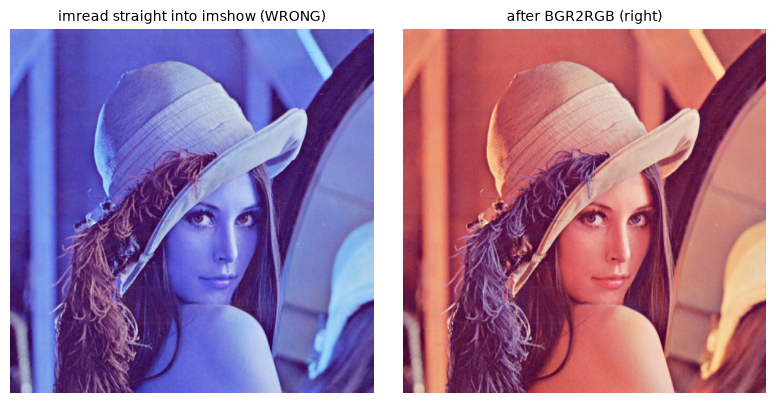

In [6]:
bgr = cv2.imread("images/lena.jpg")           # what OpenCV gives you
_imgs, _titles = [bgr, cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)], ["imread straight into imshow (WRONG)", "after BGR2RGB (right)"]
fig, axes = plt.subplots(1, 2, figsize=(4 * 2, 4), squeeze=False)
for ax, im, t in zip(axes.ravel(), _imgs, _titles):
    ax.imshow(im, cmap="gray", vmin=0, vmax=255) if im.ndim == 2 else ax.imshow(im)
    ax.set_title(t, fontsize=10); ax.axis("off")
for ax in axes.ravel()[len(_imgs):]: ax.axis("off")
plt.tight_layout(); plt.show()

## Available demo images

Run this to see what is in `images/`. All of them are the standard OpenCV sample set.

In [7]:
from pathlib import Path
for p in sorted(Path("images").iterdir()):
    im = cv2.imread(str(p))
    print(f"{p.name:16} {im.shape[1]}x{im.shape[0]}")

baboon.jpg       512x512
board.jpg        640x480
building.jpg     868x600
butterfly.jpg    493x356
fruits.jpg       512x480
left.jpg         612x459
lena.jpg         512x512
messi5.jpg       548x342
pic1.png         400x300
sudoku.png       558x563


---

## Order to work through this folder

| notebook | course assignment | core idea |
|---|---|---|
| `01_binary_thresholding` | Assignment 1 | pixels are just numbers; a mask is a comparison |
| `02_rgb_to_grayscale` | Assignment 2 | channels, weighted sums, dtype overflow |
| `03_border_and_complement` | Assignment 3 | shape manipulation, padding, inversion |
| `04_intensity_transforms` | Assignment 4 | log / gamma / piecewise-linear mappings, LUTs |
| `05_yolo_first_detection` | (bonus) | object detection, and the IoU + NMS behind it |

Each assignment notebook has stub functions that `raise NotImplementedError`.
You fill them in, then write tests for the properties listed under each task.
Testing your own code is part of the work, not an extra.